You have at your disposal 100000 images of human faces, and their occlusion label.
The goal of this challenge is to regress the percentage of the face that is occluded.
We also want to have similar performances on female and male, the gender label is given for the train database

Below is the formula of the evaluation score

$$
 Err = \frac{\sum_{i}{w_i(p_i - GT_i)^2}}{\sum_{i}{w_i}}, w_i = \frac{1}{30} + GT_i
$$

$$
Score = \frac{Err_F + Err_M}{2} + \left | Err_F - Err_M \right |
$$

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from collections import OrderedDict

import cv2

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

### Load dataframes

In [259]:
df_train = pd.read_csv("../../occlusion_datasets/train.csv", delimiter=',')
df_test = pd.read_csv("../../occlusion_datasets/test_students.csv", delimiter=',')

image_dir = "../../crops/Crop_224_5fp_100K"

In [260]:
df_train.head()

,filename,FaceOcclusion,gender
0,database3/database3/m.01w0zk1/66-FaceId-0_alig...,0.024005,1.0
1,database3/database3/m.016ywr/88-FaceId-0_align...,0.030028,1.0
2,database3/database3/m.02dfmb/105-FaceId-0_alig...,0.009984,0.0
3,database3/database3/m.01_h_s/33-FaceId-5_align...,0.255016,1.0
4,database3/database3/m.02lqkv/85-FaceId-0_align...,0.252091,1.0


In [261]:
df_test.head()

,filename
0,database3/database3/m.0256vn/81-FaceId-0_align...
1,database3/database3/m.01dgwg/29-FaceId-0_align...
2,database3/database3/m.02l0nk/72-FaceId-0_align...
3,database3/database3/m.026jp3/94-FaceId-1_align...
4,database3/database3/m.01ncgyv/24-FaceId-0_alig...


#### Remove nan values

In [262]:
df_train = df_train.dropna()
df_test = df_test.dropna()

### Split Dataframe in train and val

In [263]:
df_val = df_train.loc[:15000].reset_index()
df_train = df_train.loc[15000:].reset_index()

In [264]:
len(df_train), len(df_val), len(df_test)

(85000, 15001, 29980)

### Check that all images are read correctly

In [ ]:
for idx, row in tqdm(df_train.iterrows(), total=len(df_train)):
    try:
        filename = df_train.loc[idx, 'filename']
        img2display = Image.open(f"{image_dir}/{filename}")
    except ValueError as e:
        print(idx, e)

for idx, row in tqdm(df_val.iterrows(), total=len(df_val)):
    try:
        filename = df_val.loc[idx, 'filename']
        img2display = Image.open(f"{image_dir}/{filename}")
    except ValueError as e:
        print(idx, e)
        
for idx, row in tqdm(df_test.iterrows(), total=len(df_test)):
    try:
        filename = df_test.loc[idx, 'filename']
        img2display = Image.open(f"{image_dir}/{filename}")
    except ValueError as e:
        print(idx, e)

### Display random images

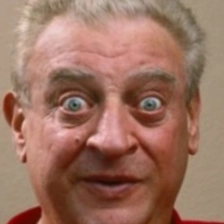

database3/database3/m.015b67/2-FaceId-0_align.webp 0.026632 1.0


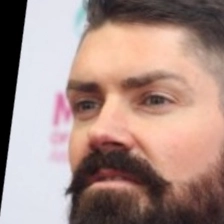

database3/database3/m.01vzrpq/96-FaceId-0_align.webp 0.007354 1.0


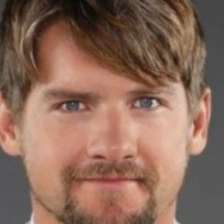

database3/database3/m.026c5yf/23-FaceId-0_align.webp 0.223351 1.0


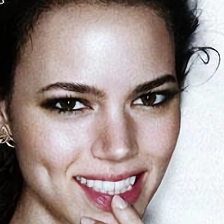

database1/img00015522.webp 0.048743 0.0


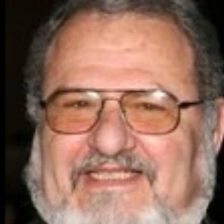

database3/database3/m.01wyy_/73-FaceId-0_align.webp 0.026625 1.0


In [244]:
for idx, row in df_train.sample(frac=1)[:5].iterrows():
    filename = row['filename']
    occlusion = row['FaceOcclusion']
    gender = row['gender']
    img2display = Image.open(f"{image_dir}/{filename}")
    display(img2display)
    print(filename, occlusion, gender)

### Make Dataset and Dataloader

In [265]:
class Dataset(torch.utils.data.Dataset):
    'Characterizes a dataset for PyTorch'
    def __init__(self, df, image_dir, training=True):
         'Initialization'
         self.training = training
         self.image_dir = image_dir
         self.df = df
         self.transform = transforms.ToTensor()
         
    def __len__(self):
        'Denotes the total number of samples'
        return len(self.df)

    def __getitem__(self, index):
        'Generates one sample of data'
        # Select sample
        row = self.df.loc[index]
        filename = row['filename']

        # Load data and get label
        img = Image.open(f"{image_dir}/{filename}")

        X = cv2.imread(f"{image_dir}/{filename}")

        if self.training:
            y = row['FaceOcclusion']
            y = np.float32(y)
            gender = row['gender']
            return X, y, gender, filename
        else:
            y = None
            gender = None
            return X, filename

In [266]:
training_set = Dataset(df_train, image_dir)
validation_set = Dataset(df_val, image_dir)
test_set = Dataset(df_test, image_dir, training=False)

params_train = {'batch_size': 1,
          'shuffle': True,
          'num_workers': 0}

params_val = {'batch_size': 1,
          'shuffle': False,
          'num_workers': 0}

training_generator = torch.utils.data.DataLoader(training_set, **params_train)
validation_generator = torch.utils.data.DataLoader(validation_set, **params_val)
test_generator = torch.utils.data.DataLoader(test_set, **params_val)

# Training-Free track

## Installation

### Face Analysis

In [ ]:
import sys
!"{sys.executable}" -m pip install insightface onnxruntime

### 3DDFA-V2

In [ ]:
!git clone https://github.com/cleardusk/3DDFA_V2.git
!"{sys.executable}" -m pip install -r 3DDFA_V2/requirements.txt

### BiSeNet

In [ ]:
!git clone https://github.com/zllrunning/face-parsing.PyTorch.git

Le modèle pré-entrainé n'est pas directement accessible depuis le repo Git, mais depuis un Drive. Voici les informations pour le récupérer en cas d'échec du téléchargement automatique.

Lien pour la copie des poids : https://drive.google.com/open?id=154JgKpzCPW82qINcVieuPH3fZ2e0P812
A placer dans un sous-dossier weights, à partir du dossier courant du notebook

In [ ]:
!"{sys.executable}" -m pip install gdown

In [ ]:
import gdown
from pathlib import Path

Path("weights").mkdir(exist_ok=True)

file_id = "154JgKpzCPW82qINcVieuPH3fZ2e0P812"
output = "weights/79999_iter.pth"

gdown.download(
    f"https://drive.google.com/uc?id={file_id}",
    output,
    quiet=False
)

## Imports

In [12]:
import cv2
import os
import sys
from pathlib import Path

In [13]:
#Face Analysis

from insightface.app import FaceAnalysis

app = FaceAnalysis(
    name='buffalo_l',
    providers=[
        'CPUExecutionProvider'
    ]
)
app.prepare(
    ctx_id=0,
    det_size=(224, 224)
)

Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/julienniol/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/julienniol/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/julienniol/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/julienniol/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/julienniol/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3,

In [14]:
# 3DDFA-V2

ROOT = Path.cwd()
THREEDDFA_PATH = ROOT / "3DDFA_V2"
sys.path.append(str(THREEDDFA_PATH))
print(THREEDDFA_PATH)

from TDDFA import TDDFA

MODEL_PATH = Path.cwd() / "3DDFA_V2" / "weights" / "mb1_120x120.pth"

cfg = {
    'arch': 'mobilenet',
    'checkpoint_fp': str(MODEL_PATH),
    'gpu_mode': False
}

tddfa = TDDFA(**cfg)

from utils.pose import viz_pose

/Users/julienniol/Documents/MS IA/IAD704 - DeepLearning/Data_Challenge/DataChallenge2026/data-challenge-42/notebooks/3DDFA_V2


In [15]:
#BiSeNet

BISENET_PATH = ROOT / "face-parsing.PyTorch"
sys.path.append(str(BISENET_PATH))

from model import BiSeNet
import torch

WEIGHTS = (
    Path.cwd()
    / "weights"
    / "79999_iter.pth"
)

assert WEIGHTS.exists()

n_classes = 19
net = BiSeNet(n_classes=n_classes)
net.load_state_dict(
    torch.load(
        WEIGHTS,
        map_location="cpu"
    )
)

device = 'mps' if torch.backends.mps.is_available() else 'cpu'
net.eval().to(device)

BiSeNet(
  (cp): ContextPath(
    (resnet): Resnet18(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm

In [33]:
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation

seg_processor = SegformerImageProcessor.from_pretrained("jonathandinu/face-parsing")
seg_model = SegformerForSemanticSegmentation.from_pretrained("jonathandinu/face-parsing")
seg_model.to(device)

/Users/julienniol/Documents/MS IA/IAD704 - DeepLearning/Data_Challenge/DataChallenge2026/data-challenge-42/venv_42/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 1172/1172 [00:00<00:00, 11085.48it/s]


SegformerForSemanticSegmentation(
  (segformer): SegformerModel(
    (stages): ModuleList(
      (0): SegformerStage(
        (patch_embeddings): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(3, 64, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
          (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
        )
        (blocks): ModuleList(
          (0): SegformerLayer(
            (layernorm_before): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
            (attention): SegformerAttention(
              (q_proj): Linear(in_features=64, out_features=64, bias=True)
              (k_proj): Linear(in_features=64, out_features=64, bias=True)
              (v_proj): Linear(in_features=64, out_features=64, bias=True)
              (o_proj): Linear(in_features=64, out_features=64, bias=True)
              (sequence_reduction): SegformerSequenceReduction(
                (sequence_reduction): Conv2d(64, 64, kernel_size=(8, 8), s

## Pipeline and configuration

In [197]:
from torchvision import transforms

CLASSES = {
    0: "background",
    1: "skin",
    2: "left_eyebrow",
    3: "right_eyebrow",
    4: "left_eye",
    5: "right_eye",
    6: "eyeglasses",
    7: "left_ear",
    8: "right_ear",
    9: "earrings",
    10: "nose",
    11: "mouth",
    12: "upper_lip",
    13: "lower_lip",
    14: "neck",
    15: "necklace",
    16: "cloth",
    17: "hair",
    18: "hat"
}

VISIBLE_FACE_CLASSES_B = [
    0,   # background (in case of missed detection)
    1,   # skin
    2,   # left eyebrow
    3,   # right eyebrow
    4,   # left eye
    5,   # right eye
    6,   # eyeglasses
    10,  # nose
    11,  # mouth
    12,  # upper lip
    13  # lower lip
]

VISIBLE_FACE_CLASSES_S = [
    1,   # skin
    2,  # nose
    3,   # eyeglasses
    4,   # left eye
    5,   # right eye
    6,   # left eyebrow
    7,   # right eyebrow
    10,  # mouth
    11,  # upper lip
    12  # lower lip
]

W_B = 0.4
W_S = 0.6
CAL_BM = 0.9
CAL_BF = 1.2
CAL_SM = 0.9
CAL_SF = 1.1

to_tensor = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.485, 0.456, 0.406),
        (0.229, 0.224, 0.225)
    ),
])

In [17]:
def overlay_mask(
    image,
    mask,
    color,
    alpha=0.4
):

    overlay = image.copy()

    overlay[mask > 0] = color

    blended = cv2.addWeighted(
        overlay,
        alpha,
        image,
        1 - alpha,
        0
    )

    return blended

In [199]:
def occlusion_computation(app,img,fit_method = "hull",seg_method="bisenet",display_results = False):

    #Face Detection
    img = cv2.resize(img, (512, 512), interpolation=cv2.INTER_CUBIC)
    faces = app.get(img)
    if faces:
        face = faces[0]
        bbox = face.bbox
    else:
        return 0.0
    
    #Gender prediction
    pred_gender = face.sex

    #3D Face estimation (3DDFA-V2)
    boxes = [bbox]
    param_lst, roi_box_lst = tddfa(img, boxes)
    ver_lst = tddfa.recon_vers(
        param_lst,
        roi_box_lst,
        dense_flag=True
    )

    #Surface rendering 
    mask_theoretical = np.zeros(
        img.shape[:2],
        dtype=np.uint8
    )
    pts = ver_lst[0][:2, :].T.astype(np.int32)
    if fit_method == "hull":
        hull = cv2.convexHull(pts)
        cv2.fillConvexPoly(
            mask_theoretical,
            hull,
            1
        )
        scale_x = 0.9
        scale_y = 1.05
        tx = 15
        ty = -10
        M = np.array([
            [scale_x, 0, tx],
            [0, scale_y, ty]
        ], dtype=np.float32)
        mask_theoretical = cv2.warpAffine(mask_theoretical,M,dsize=img.shape[:2])

    if fit_method == "ellipse":
        ellipse = cv2.fitEllipse(pts)
        cv2.ellipse(
            mask_theoretical,
            ellipse,
            1,
            -1
        )
        scale_x = 1.0
        scale_y = 1.25
        tx = 0
        ty = -35
        M = np.array([
            [scale_x, 0, tx],
            [0, scale_y, ty]
        ], dtype=np.float32)
        mask_theoretical = cv2.warpAffine(mask_theoretical,M,dsize=img.shape[:2])

    ### BiSeNet
    # Semantic segmentation
    input_tensor = to_tensor(img)
    input_tensor = input_tensor.unsqueeze(0).to(device)
    out = net(input_tensor)[0]
    parsing_b = out.squeeze(0).cpu().numpy().argmax(0)

    # Filtering non-occluded classes
    visible_skin_mask_b = np.isin(
        parsing_b,
        VISIBLE_FACE_CLASSES_B
    ).astype(np.uint8)

    # Occlusion score computation
    visible_pixels_b = np.sum(visible_skin_mask_b & mask_theoretical)
    total_pixels = np.sum(mask_theoretical)
    visible_ratio_b = visible_pixels_b / total_pixels
    occlusion_score_b = 1.0 - visible_ratio_b
    if pred_gender == 'M':
        occlusion_score_b *= CAL_BM
    elif pred_gender == 'F':
        occlusion_score_b *= CAL_BF

    ### SegFormer
    # Semantic segmentation
    inputs = seg_processor(images=img, return_tensors="pt").to(device)
    outputs = seg_model(**inputs)
    logits = outputs.logits 
    h, w = img.shape[:2]
    image_size = (h, w)
    upsampled_logits = nn.functional.interpolate(logits,
                    size=image_size, # H x W
                    mode='bilinear',
                    align_corners=False)
    labels = upsampled_logits.argmax(dim=1)[0]
    parsing_s = labels.cpu().numpy()

    # Filtering non-occluded classes
    visible_skin_mask_s = np.isin(
        parsing_s,
        VISIBLE_FACE_CLASSES_S
    ).astype(np.uint8)

    # Occlusion score computation
    visible_pixels_s = np.sum(visible_skin_mask_s & mask_theoretical)
    total_pixels = np.sum(mask_theoretical)
    visible_ratio_s = visible_pixels_s / total_pixels
    occlusion_score_s = 1.0 - visible_ratio_s
    if pred_gender == 'M':
        occlusion_score_s *= CAL_SM
    elif pred_gender == 'F':
        occlusion_score_s *= CAL_SF

    #Ensembling predictions
    occlusion_score = W_B * occlusion_score_b + W_S * occlusion_score_s

    # Graphical results
    if display_results:
        # Overlay theoretical face
        vis1 = overlay_mask(
            img,
            mask_theoretical,
            color=(0,255,0),
            alpha=0.35
        )
        # Overlay visible skin 
        vis2 = overlay_mask(
            vis1,
            visible_skin_mask_b,
            color=(255,0,0),
            alpha=0.35
        )
        # Overlay visible skin 
        vis3 = overlay_mask(
            vis2,
            visible_skin_mask_s,
            color=(255,0,0),
            alpha=0.35
        )
        # Plot
        plt.figure(figsize=(8,8))
        plt.imshow(
            cv2.cvtColor(
                vis3,
                cv2.COLOR_BGR2RGB
            )
        )
        plt.axis("off")
        plt.title(
            f"{filename}\n"
            f"GT occlusion={occlusion:.3f} | {gender} - {pred_gender} | Pred occlusion={occlusion_score:.3f}"
        )
        plt.show()

    return occlusion_score

## Load random image and apply pipeline

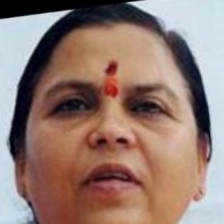

database3/database3/m.0232zf/48-FaceId-0_align.webp 0.060284 0.0


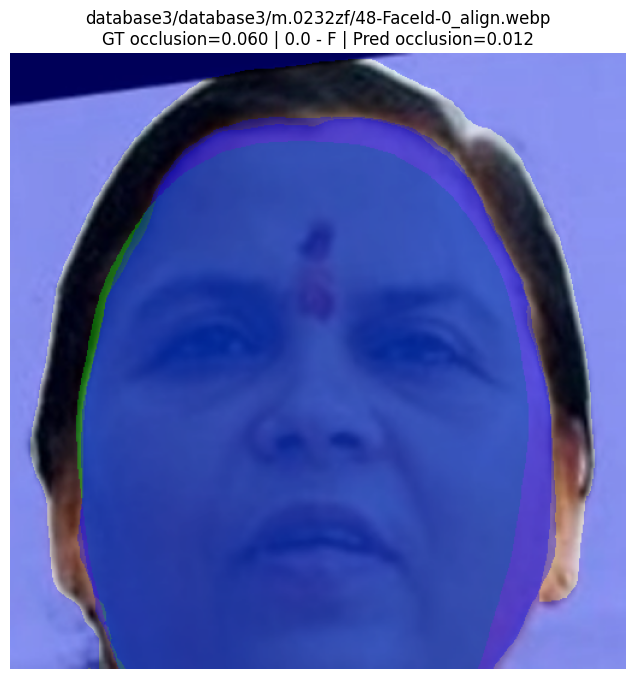

Score :0.012


In [274]:
for idx, row in df_train.sample(frac=1)[:1].iterrows():
    filename = row['filename']
    occlusion = row['FaceOcclusion']
    gender = row['gender']
    img2display = Image.open(f"{image_dir}/{filename}")
    display(img2display)
    print(filename, occlusion, gender)

img = cv2.imread(f"{image_dir}/{filename}")

occlusion_score = occlusion_computation(app,img,fit_method="hull",seg_method="segformer",display_results=True)
print(f"Score :{occlusion_score:.3f}")

## Generate results on validation dataset

In [20]:
def error_fn(df):
    pred = df.loc[:, "pred"]
    ground_truth = df.loc[:, "target"]
    weight = 1/30 + ground_truth

    return np.sum(((pred - ground_truth)**2) * weight, axis=0) / np.sum(weight, axis=0)

def metric_fn(female, male):
    err_male = error_fn(male)
    err_female = error_fn(female)
    return (err_male + err_female) / 2 + abs(err_male - err_female)

In [275]:
results_list = []
for batch_idx, (X, y, gender, filename) in tqdm(enumerate(validation_generator), total=len(validation_generator)):
    for i in range(len(X)):
        img = cv2.imread(os.path.join(image_dir, filename[i]))
        y_pred = occlusion_computation(app,img,fit_method="hull")
        results_list.append({'filename': filename[i],
                                'pred': float(y_pred),
                                'target': float(y[i]),
                                'gender': float(gender[i]),
                                'error' : float(torch.abs(y_pred-y[i]))
                                })
results_df = pd.DataFrame(results_list)

100%|██████████| 15001/15001 [3:31:04<00:00,  1.18it/s]     


In [276]:
results_df.head()

,filename,pred,target,gender,error
0,database3/database3/m.01w0zk1/66-FaceId-0_alig...,0.034000,0.024005,1.0,0.009995
1,database3/database3/m.016ywr/88-FaceId-0_align...,0.053618,0.030028,1.0,0.023590
2,database3/database3/m.02dfmb/105-FaceId-0_alig...,0.046138,0.009984,0.0,0.036154
3,database3/database3/m.01_h_s/33-FaceId-5_align...,0.315969,0.255016,1.0,0.060953
4,database3/database3/m.02lqkv/85-FaceId-0_align...,0.218227,0.252091,1.0,0.033864


<Axes: >

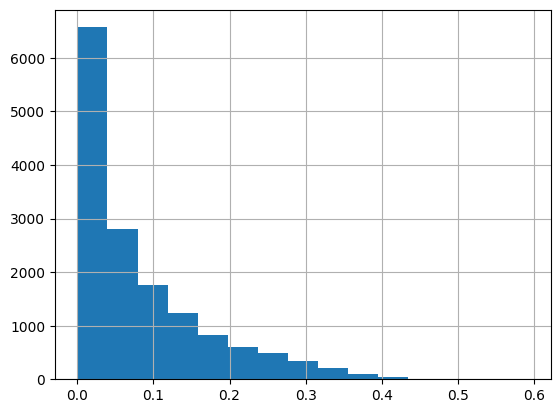

In [277]:
import matplotlib.pyplot as plt
results_df['target'].hist(bins=15)

<Axes: >

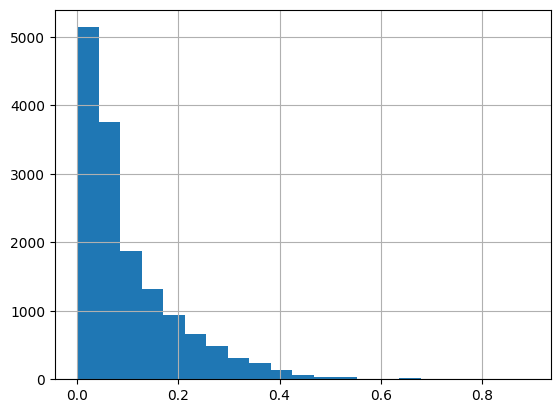

In [278]:
import matplotlib.pyplot as plt
results_df['pred'].hist(bins=21)

In [279]:
results_male = results_df.loc[results_df["gender"] == 1.0]
results_female = results_df.loc[results_df["gender"] == 0.0]

In [280]:
er_m = error_fn(results_df)
print(f"Error Metric : {er_m:.5f}")

Error Metric : 0.00517


In [281]:
fn_m = metric_fn(results_male, results_female)
print(f"Fairness Metric : {fn_m:.5f}")

Fairness Metric : 0.00677


In [282]:
results_df['bin'] = np.floor(results_df['target']*20)
error_df = results_df[['bin','error','gender']]

In [283]:
mae = error_df.groupby(['bin'])['error'].mean()
mae_fm = error_df.groupby(['bin','gender'])['error'].mean().reset_index()
mae_male = mae_fm.loc[mae_fm["gender"] == 1.0]
mae_female = mae_fm.loc[mae_fm["gender"] == 0.0]

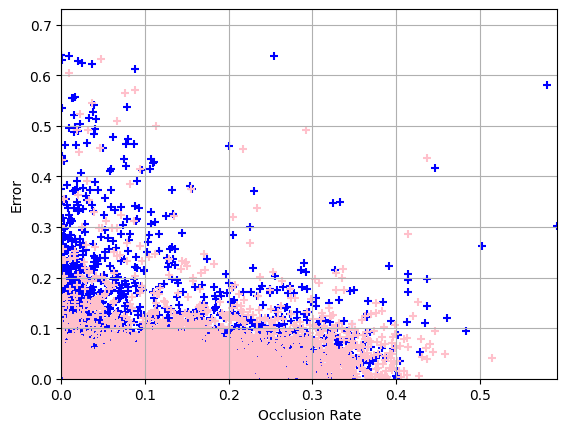

In [284]:
plt.scatter(x=results_male['target'],y=results_male['error'], marker='+', label="predicted error", c='blue')
plt.scatter(x=results_female['target'],y=results_female['error'], marker='+', label="predicted error", c='pink')
plt.xlabel("Occlusion Rate")
plt.ylabel("Error")
plt.xlim((0,max(results_df['target'])))
plt.ylim((0,max(results_df['error'])))
plt.grid()
plt.show()

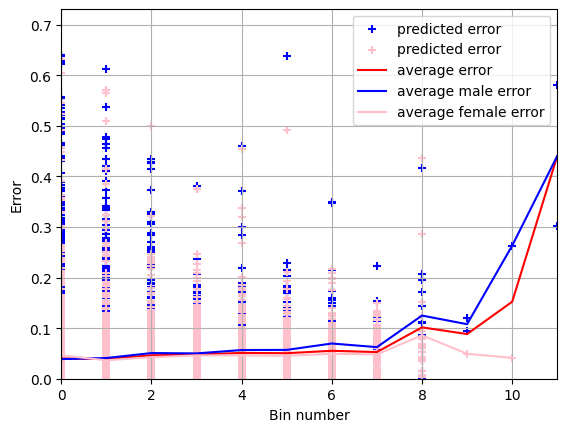

In [285]:
error_male = error_df.loc[error_df["gender"] == 1.0]
error_female = error_df.loc[error_df["gender"] == 0.0]
plt.scatter(x=error_male['bin'],y=error_male['error'], marker='+', label="predicted error", c='blue')
plt.scatter(x=error_female['bin'],y=error_female['error'], marker='+', label="predicted error", c='pink')
plt.plot(mae, color='r', label="average error")
plt.plot(mae_male['bin'],mae_male['error'], color='b', label="average male error")
plt.plot(mae_female['bin'],mae_female['error'], color='pink', label="average female error")
plt.xlabel("Bin number")
plt.ylabel("Error")
plt.xlim((0,max(error_df['bin'])))
plt.ylim((0,max(error_df['error'])))
plt.grid()
plt.legend()
plt.show()

In [286]:
from evaluate_with_reweighting import evaluate_predictions
results = evaluate_predictions(results_df)


FULL VAL REWEIGHTED EVALUATION

Sample size: 15001 images (F=4867, M=10134)

distribution              err_F      err_M   mean_err        gap      score
-----------------------------------------------------------------
val natif (empiric)     0.00425    0.00593    0.00517    0.00168    0.00677
reweighted brief        0.00437    0.00828    0.00702    0.00391    0.01024
reweighted spread       0.00425    0.01566    0.01196    0.01140    0.02136
reweighted heavy        0.00425    0.02533    0.01849    0.02108    0.03587

Per-bin breakdown:
gender         bin    n  mean_pred  mean_gt    bias    mse  weighted_err
     F [0.00,0.05) 1079     0.0687   0.0255  0.0432 0.0069        0.0066
     F [0.05,0.10) 1183     0.0873   0.0746  0.0127 0.0038        0.0038
     F [0.10,0.15)  969     0.1223   0.1234 -0.0011 0.0034        0.0034
     F [0.15,0.20)  615     0.1761   0.1728  0.0033 0.0038        0.0037
     F [0.20,0.30)  705     0.2624   0.2450  0.0174 0.0042        0.0042
     F [0.30,0.50)

# Generate test predictions

### Make predictions on test dataset

In [287]:
training_set = Dataset(df_train, image_dir)
validation_set = Dataset(df_val, image_dir)
test_set = Dataset(df_test, image_dir, training=False)

params_train = {'batch_size': 1,
          'shuffle': True,
          'num_workers': 0}

params_val = {'batch_size': 1,
          'shuffle': False,
          'num_workers': 0}

training_generator = torch.utils.data.DataLoader(training_set, **params_train)
validation_generator = torch.utils.data.DataLoader(validation_set, **params_val)
test_generator = torch.utils.data.DataLoader(test_set, **params_val)

In [289]:
results_list = []
with torch.inference_mode():
    for batch_idx, (X, filename) in tqdm(enumerate(test_generator), total=len(test_generator)):
        for i in range(len(X)):
            img = cv2.imread(os.path.join(image_dir, filename[i]))
            y_pred = occlusion_computation(app,img,fit_method="hull")
            results_list.append({'filename': filename[i],
                                 'FaceOcclusion': float(y_pred),
                                 })
results_df = pd.DataFrame(results_list)

 28%|██▊       | 8397/29980 [54:39<3:27:21,  1.73it/s]   

: 

In [ ]:
results_df.head()

### Export predictions
Note: We need to add a dummy 'gender' column for the hfactory upload.

In [ ]:
results_df['gender'] = 'x'
results_df.to_csv("test_predictions.csv", sep=',', index=False)

# Appendix : Run pipeline cells one by one

## Load random image

In [ ]:
for idx, row in df_train.sample(frac=1)[:1].iterrows():
    filename = row['filename']
    occlusion = row['FaceOcclusion']
    gender = row['gender']
    img2display = Image.open(f"{image_dir}/{filename}")
    display(img2display)
    print(filename, occlusion, gender)

img = cv2.imread(f"{image_dir}/{filename}")

## Face Detection

In [ ]:
faces = app.get(img)
face = faces[0]
bbox = face.bbox
kps = face.kps

x1, y1, x2, y2 = bbox.astype(int)
crop = img[y1:y2, x1:x2]

## 3D Pose Estimation

In [ ]:
boxes = [bbox]
param_lst, roi_box_lst = tddfa(img, boxes)
ver_lst = tddfa.recon_vers(
    param_lst,
    roi_box_lst,
    dense_flag=True
)

In [ ]:
pose = param_lst[0][:12]

In [ ]:
pts = ver_lst[0][:2, :].T.astype(np.int32)
hull = cv2.convexHull(pts)

mask_theoretical = np.zeros(
    img.shape[:2],
    dtype=np.uint8
)

cv2.fillConvexPoly(
    mask_theoretical,
    hull,
    1
)

## Segmentation sémantique visage

In [ ]:
input_tensor = to_tensor(img)
input_tensor = input_tensor.unsqueeze(0).to(device)

out = net(input_tensor)[0]

parsing = out.squeeze(0).cpu().numpy().argmax(0)

In [ ]:
# run inference on image
inputs = seg_processor(images=img, return_tensors="pt").to(device)
outputs = seg_model(**inputs)
logits = outputs.logits  # shape (batch_size, num_labels, ~height/4, ~width/4)

h, w = img.shape[:2]
image_size = (h, w)
# resize output to match input image dimensions
upsampled_logits = nn.functional.interpolate(logits,
                size=image_size, # H x W
                mode='bilinear',
                align_corners=False)

# get label masks
labels = upsampled_logits.argmax(dim=1)[0]

# move to CPU to visualize in matplotlib
parsing = labels.cpu().numpy()

## Visualize segmentation results

In [ ]:
CLASS_COLORS = {
    0:  (10,10,10),         # background
    1:  (255,220,180),   # skin
    2:  (120,60,20),     # left eyebrow
    3:  (120,60,20),     # right eyebrow
    4:  (0,255,0),       # left eye
    5:  (0,255,0),       # right eye
    6:  (255,0,255),     # glasses
    7:  (255,255,0),     # left ear
    8:  (255,255,0),     # right ear
    9:  (255,128,0),     # earrings
    10: (255,0,0),       # nose
    11: (180,0,255),     # mouth
    12: (255,100,180),   # upper lip
    13: (255,100,180),   # lower lip
    14: (0,180,255),     # neck
    15: (0,100,255),     # necklace
    16: (100,100,100),   # cloth
    17: (0,0,255),       # hair
    18: (80,80,80)       # hat
}

In [ ]:
CLASS_NAMES = {
    0: "background",
    1: "skin",
    6: "left eyebrow",
    7: "right eyebrow",
    4: "left eye",
    5: "right eye",
    3: "glasses",
    8: "left ear",
    9: "right ear",
    15: "earrings",
    2: "nose",
    10: "mouth",
    11: "upper lip",
    12: "lower lip",
    17: "neck",
    16: "necklace",
    18: "cloth",
    13: "hair",
    14: "hat"
}

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.patches import Patch


color_mask = np.zeros(
    (*parsing.shape, 3),
    dtype=np.uint8
)

for class_id, color in CLASS_COLORS.items():

    color_mask[parsing == class_id] = color


masked_color = np.zeros_like(color_mask)

masked_color[mask_theoretical > 0] = \
    color_mask[mask_theoretical > 0]


overlay = cv2.addWeighted(
    img,
    0.6,
    masked_color,
    0.4,
    0
)


plt.figure(figsize=(10,10))

plt.imshow(
    cv2.cvtColor(
        overlay,
        cv2.COLOR_BGR2RGB
    )
)

plt.axis("off")


legend_elements = []

present_classes = np.unique(
    parsing[mask_theoretical > 0]
)

for class_id in present_classes:

    bgr = np.array(
        CLASS_COLORS[class_id]
    )

    rgb = bgr[::-1] / 255.0

    legend_elements.append(
        Patch(
            facecolor=rgb,
            label=CLASS_NAMES[class_id]
        )
    )

plt.legend(
    handles=legend_elements,
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.show()

In [ ]:
masked_parsing = parsing[
    mask_theoretical > 0
]

unique, counts = np.unique(
    masked_parsing,
    return_counts=True
)

total_pixels = len(masked_parsing)

rows = []

for class_id, pixel_count in zip(unique, counts):

    rows.append({
        "class_id": int(class_id),
        "class_name": CLASS_NAMES[class_id],
        "pixels": int(pixel_count),
        "ratio": pixel_count / total_pixels
    })

stats_df = pd.DataFrame(rows)

stats_df = stats_df.sort_values(
    "pixels",
    ascending=False
)

stats_df.loc[len(stats_df)] = {
    "class_id": -1,
    "class_name": "TOTAL",
    "pixels": stats_df["pixels"].sum(),
    "ratio": stats_df["ratio"].sum()
}

display(stats_df)

## Compute occlusion score

In [ ]:
visible_skin_mask = np.isin(
    parsing,
    VISIBLE_FACE_CLASSES
).astype(np.uint8)

In [ ]:
visible_pixels = np.sum(
    visible_skin_mask & mask_theoretical
)
print(visible_pixels)

total_pixels = np.sum(
    mask_theoretical
)
print(total_pixels)

visible_ratio = visible_pixels / total_pixels

occlusion_score = 1.0 - visible_ratio

print(occlusion_score)

## Results visualization

In [ ]:
# Overlay theoretical face
vis1 = overlay_mask(
    img,
    mask_theoretical,
    color=(0,255,0),
    alpha=0.35
)

plt.figure(figsize=(8,8))

plt.imshow(
    cv2.cvtColor(
        vis1,
        cv2.COLOR_BGR2RGB
    )
)

plt.axis("off")

plt.title(
    f"{filename}\n"
    f"GT occlusion={occlusion:.3f} | {gender} | Pred occlusion={occlusion_score:.3f}"
)

plt.show()

In [ ]:
# Overlay visible skin
vis2 = overlay_mask(
    vis1,
    visible_skin_mask,
    color=(255,0,0),
    alpha=0.35
)

plt.figure(figsize=(8,8))

plt.imshow(
    cv2.cvtColor(
        vis2,
        cv2.COLOR_BGR2RGB
    )
)

plt.axis("off")

plt.title(
    f"{filename}\n"
    f"GT occlusion={occlusion:.3f} | {gender} | Pred occlusion={occlusion_score:.3f}"
)

plt.show()

### Test Florence 2 pour détection "Hat"

In [ ]:
#Florence-2

from transformers import AutoProcessor, Florence2ForConditionalGeneration

fl_model = Florence2ForConditionalGeneration.from_pretrained("florence-community/Florence-2-base", device_map="auto")
fl_processor = AutoProcessor.from_pretrained("florence-community/Florence-2-base")

In [ ]:
visible_skin_mask = np.isin(
    parsing,
    VISIBLE_FACE_CLASSES
).astype(np.uint8)

In [ ]:
hat_test = (masked_parsing == 14)
if np.sum(hat_test)>0:
    hat_ratio = stats_df.loc[
        stats_df["class_name"]=="hat",
        "ratio"
    ].iloc[0]
else:
    hat_ratio = 0.0

if hat_ratio > 0.99:
    task = "<REFERRING_EXPRESSION_SEGMENTATION>"
    text_input = "head cover"
    task_prompt = task + text_input
    inputs = fl_processor(text=task_prompt, images=img, return_tensors="pt").to(fl_model.device)

    generated_ids = fl_model.generate(
        **inputs,
        max_new_tokens=1024,
        num_beams=3,
    )
    generated_text = fl_processor.batch_decode(generated_ids, skip_special_tokens=False)[0]

    h, w = img.shape[:2]
    image_size = (w, h)

    parsed_answer = fl_processor.post_process_generation(generated_text, task=task, image_size=image_size)
    result = parsed_answer[task]
    polygons = result['polygons']

    h, w = visible_skin_mask.shape

    hat_mask = np.zeros(
        (h, w),
        dtype=np.uint8
    )

    polygon = np.array(
        polygons[0],
        dtype=np.int32
    ).reshape(-1,2)

    print(polygon)

    cv2.fillPoly(
        hat_mask,
        [polygon],
        1
    )


    hat_bisenet = (parsing == 18).astype(bool)
    hat_mask = hat_mask.astype(bool)
    false_hat = hat_bisenet & (~hat_mask)
    parsing[false_hat] = 1
    parsing[hat_mask] = 18

    hat_corrected = (parsing == 18)